# Introducción

Las series temporales son una secuencia o serie de puntos de datos en los que interviene el componente temporal a lo largo de toda la ocurrencia y Analizar estos datos de series temporales con determinadas herramientas y técnicas se denomina análisis de series temporales.

[Click Here](https://www.analyticsvidhya.com/blog/2021/06/time-series-analysis-a-comprehensive-guide/) para saber más sobre el análisis de series temporales.

Aquí, voy a visualizar y predecir el precio de diferentes tipos de criptomonedas:
- Bitcoin
- Cardano
- Dogecoin
- Ethereum


## Breve introducción a XGBoost

**XGBoost son las siglas de "Extreme Gradient Boosting". XGBoost es una biblioteca distribuida optimizada de refuerzo de gradiente diseñada para ser altamente eficiente, flexible y portátil. Implementa algoritmos de aprendizaje automático en el marco del Gradient Boosting. Proporciona un árbol paralelo de refuerzo para resolver muchos problemas de ciencia de datos de una manera rápida y precisa.**

[Click here](https://medium.com/analytics-vidhya/introduction-to-xgboost-algorithm-d2e7fad76b04) para saber más sobre XGBoost.

## Import Libraries

In [100]:
!pip install colorama


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [101]:
import os
import pandas as pd
import numpy as np
import math
import datetime as dt

from sklearn.metrics import mean_squared_error, mean_absolute_error, explained_variance_score, r2_score
from sklearn.metrics import mean_poisson_deviance, mean_gamma_deviance, accuracy_score
from sklearn.preprocessing import MinMaxScaler

from itertools import cycle
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import seaborn as sns
import matplotlib.pyplot as plt
from colorama import Fore

## Import Dataset

## Bitcoin

**Bitcoin es una moneda digital que funciona sin control central ni supervisión de bancos o gobiernos. En su lugar, se basa en un software de igual a igual y en la criptografía. Un libro de contabilidad público registra todas las transacciones de bitcoin y se guardan copias en servidores de todo el mundo.**

In [102]:
path = './'

In [103]:
!pip install yfinance


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [104]:
import yfinance as yf

# Definir el ticker de la criptomoneda
crypto = "BTC-USD"

In [105]:
# Descargar datos históricos (últimos años, por ejemplo)
bitcoindf = yf.download(crypto, start="2015-01-01", end="2026-04-20")

[*********************100%***********************]  1 of 1 completed


In [106]:
bitcoindf.describe()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,4127.000000,4127.000000,4127.000000,4127.000000,4.127000e+03
mean,28818.324036,29377.183560,28189.862328,28801.548277,2.273854e+10
std,32322.109661,32866.070892,31727.639784,32318.215032,2.301548e+10
min,178.102997,211.731003,171.509995,176.897003,7.860650e+06
25%,3857.507568,3926.743408,3764.942139,3854.222778,2.932690e+09
50%,11892.803711,12144.623047,11604.599609,11881.647461,1.837228e+10
75%,46192.458984,47218.062500,44468.998047,46153.265625,3.469939e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [107]:
import pandas as pd

# Renombrar las columnas para prescindir del nombre de la criptomoneda
bitcoindf.columns = [col[0] if isinstance(col, tuple) else col for col in bitcoindf.columns]

# Asegurarte de que el índice sea la columna `Date`
bitcoindf.reset_index(inplace=True)

# Renombrar 'Date' si es necesario
bitcoindf.rename(columns={'index': 'Date'}, inplace=True)

# Mostrar el DataFrame procesado
print(bitcoindf.head())


        Date       Close        High         Low        Open    Volume
0 2015-01-01  314.248993  320.434998  314.002991  320.434998   8036550
1 2015-01-02  315.032013  315.838989  313.565002  314.079010   7860650
2 2015-01-03  281.082001  315.149994  281.082001  314.846008  33054400
3 2015-01-04  264.195007  287.230011  257.612000  281.145996  55629100
4 2015-01-05  274.473999  278.341003  265.084015  265.084015  43962800


In [108]:
#bitcoindf = pd.read_csv('data/Bitcoin/Bitcoin/BTC-USD.csv')
bitcoindf = bitcoindf.rename(columns={'Date': 'date','Open':'open','High':'high','Low':'low','Close':'close',
                                'Adj Close':'adj_close','Volume':'volume'})
bitcoindf.head()

,date,close,high,low,open,volume
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


## Dogecoin

**Dogecoin se utiliza principalmente para dar propinas a los usuarios en Reddit y Twitter, pero también es aceptada como método de pago por unas pocas docenas de comerciantes. Se puede utilizar para comprar comida, suministros domésticos e incluso dominios de sitios web.**

In [109]:
# Definir el ticker de la criptomoneda
crypto = "DOGE-USD"

# Descargar datos históricos (últimos 6 meses, por ejemplo)
dogecoindf = yf.download(crypto,  start="2015-01-01", end="2026-04/20")



[*********************100%***********************]  1 of 1 completed

1 Failed download:
['DOGE-USD']: ValueError("time data '2026-04/20' does not match format '%Y-%m-%d'")


In [110]:
# Renombrar las columnas para prescindir del nombre de la criptomoneda
dogecoindf.columns = [col[0] if isinstance(col, tuple) else col for col in dogecoindf.columns]

# Asegurarte de que el índice sea la columna `Date`
dogecoindf.reset_index(inplace=True)

# Renombrar 'Date' si es necesario
dogecoindf.rename(columns={'index': 'Date'}, inplace=True)

# Mostrar el DataFrame procesado
print(dogecoindf.head())


Empty DataFrame
Columns: [Date, Adj Close, Close, High, Low, Open, Volume]
Index: []


In [111]:
#dogecoindf = pd.read_csv('data/Bitcoin/Dogecoin/DOGE-USD.csv')
dogecoindf = dogecoindf.rename(columns={'Date': 'date','Open':'open','High':'high','Low':'low','Close':'close',
                                'Adj Close':'adj_close','Volume':'volume'})
dogecoindf.head()

,date,adj_close,close,high,low,open,volume


## Ethereum

**Ethereum opera en una red informática descentralizada, o libro de contabilidad distribuido llamado blockchain, que gestiona y rastrea la moneda. Puede ser útil pensar en un blockchain como un recibo de todas las transacciones que han tenido lugar en la criptomoneda.**

In [112]:
crypto = "ETH-USD"

# Descargar datos históricos (últimos 6 meses, por ejemplo)
ethereumdf = yf.download(crypto,  start="2020-01-01", end="2026-04-20")



[*********************100%***********************]  1 of 1 completed


In [113]:
# Renombrar las columnas para prescindir del nombre de la criptomoneda
ethereumdf.columns = [col[0] if isinstance(col, tuple) else col for col in ethereumdf.columns]

# Asegurarte de que el índice sea la columna `Date`
ethereumdf.reset_index(inplace=True)

# Renombrar 'Date' si es necesario
ethereumdf.rename(columns={'index': 'Date'}, inplace=True)

# Mostrar el DataFrame procesado
print(ethereumdf.head())


        Date       Close        High         Low        Open       Volume
0 2020-01-01  130.802002  132.835358  129.198288  129.630661   7935230330
1 2020-01-02  127.410179  130.820038  126.954910  130.820038   8032709256
2 2020-01-03  134.171707  134.554016  126.490021  127.411263  10476845358
3 2020-01-04  135.069366  136.052719  133.040558  134.168518   7430904515
4 2020-01-05  136.276779  139.410202  135.045624  135.072098   7526675353


In [114]:
#ethereumdf = pd.read_csv('data/Bitcoin/Ethereum/ETH-USD.csv')
ethereumdf = ethereumdf.rename(columns={'Date': 'date','Open':'open','High':'high','Low':'low','Close':'close',
                                'Adj Close':'adj_close','Volume':'volume'})
ethereumdf.head()

,date,close,high,low,open,volume
0,2020-01-01,130.802002,132.835358,129.198288,129.630661,7935230330
1,2020-01-02,127.410179,130.820038,126.954910,130.820038,8032709256
2,2020-01-03,134.171707,134.554016,126.490021,127.411263,10476845358
3,2020-01-04,135.069366,136.052719,133.040558,134.168518,7430904515
4,2020-01-05,136.276779,139.410202,135.045624,135.072098,7526675353


## Cardano

**La blockchain de cardano puede utilizarse para construir contratos inteligentes y, a su vez, crear aplicaciones y protocolos descentralizados. Además, la capacidad de enviar y recibir fondos al instante a través de, por tarifas mínimas, tienen muchas aplicaciones en el mundo de los negocios y las finanzas.**.

In [115]:
crypto = "ADA-USD"

# Descargar datos históricos (últimos 6 meses, por ejemplo)
cardanodf = yf.download(crypto,  start="2020-01-01", end="2026-02-08")




[*********************100%***********************]  1 of 1 completed


In [116]:
# Renombrar las columnas para prescindir del nombre de la criptomoneda
cardanodf.columns = [col[0] if isinstance(col, tuple) else col for col in cardanodf.columns]

# Asegurarte de que el índice sea la columna `Date`
cardanodf.reset_index(inplace=True)

# Renombrar 'Date' si es necesario
cardanodf.rename(columns={'index': 'Date'}, inplace=True)

# Mostrar el DataFrame procesado
print(cardanodf.head())

        Date     Close      High       Low      Open    Volume
0 2020-01-01  0.033458  0.033813  0.032704  0.032832  22948374
1 2020-01-02  0.032751  0.033507  0.032448  0.033474  20843934
2 2020-01-03  0.034180  0.034427  0.032491  0.032748  30162644
3 2020-01-04  0.034595  0.034685  0.033872  0.034191  29535781
4 2020-01-05  0.034721  0.035356  0.034545  0.034574  21479178


In [117]:
#cardanodf = pd.read_csv('data/Bitcoin/Cardano/ADA-USD.csv')
cardanodf = cardanodf.rename(columns={'Date': 'date','Open':'open','High':'high','Low':'low','Close':'close',
                                'Adj Close':'adj_close','Volume':'volume'})
cardanodf.head()

,date,close,high,low,open,volume
0,2020-01-01,0.033458,0.033813,0.032704,0.032832,22948374
1,2020-01-02,0.032751,0.033507,0.032448,0.033474,20843934
2,2020-01-03,0.034180,0.034427,0.032491,0.032748,30162644
3,2020-01-04,0.034595,0.034685,0.033872,0.034191,29535781
4,2020-01-05,0.034721,0.035356,0.034545,0.034574,21479178


# Preprocesado

#### Reemplazar valores None o Null con la técnica de relleno hacia delante utilizando la función *fillna*.

El método fillna permite sustituir los valores nulos de una estructura pandas por otro valor según ciertos criterios: pueden sustituirse por un valor concreto o bien puede utilizarse el anterior o posterior valor no nulo (en el caso de los dataframes habrá que especificar el eje sobre el que queremos aplicar la función).

- Si especificamos el método "backward fill" ("bfill"), los valores nulos se han rellenado con el siguiente valor no nulo.
- Si aplicamos el método de "forward fill" a lo largo del eje 0 (eje por defecto), los valores nulos se rellenan con el valor anterior no nulo.

In [118]:
bitcoindf = bitcoindf.ffill()
dogecoindf = dogecoindf.ffill()
ethereumdf = ethereumdf.ffill()
cardanodf = cardanodf.ffill()

#### Convertir la columna Fecha en formato Datatime

In [119]:
bitcoindf.head()

,date,close,high,low,open,volume
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


In [120]:
bitcoindf.info()

<class 'pandas.DataFrame'>
RangeIndex: 4127 entries, 0 to 4126
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    4127 non-null   datetime64[s]
 1   close   4127 non-null   float64      
 2   high    4127 non-null   float64      
 3   low     4127 non-null   float64      
 4   open    4127 non-null   float64      
 5   volume  4127 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 193.6 KB


In [121]:
bitcoindf['date'] = pd.to_datetime(bitcoindf.date)
bitcoindf.head().style.set_properties(subset=['date','close'], **{'background-color': 'skyblue'})

,date,close,high,low,open,volume
0,2015-01-01 00:00:00,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02 00:00:00,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03 00:00:00,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04 00:00:00,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05 00:00:00,274.473999,278.341003,265.084015,265.084015,43962800


In [122]:
dogecoindf['date'] = pd.to_datetime(dogecoindf.date)
dogecoindf.head().style.set_properties(subset=['date','close'], **{'background-color': 'pink'})

,date,adj_close,close,high,low,open,volume


In [123]:
ethereumdf['date'] = pd.to_datetime(ethereumdf.date)
ethereumdf.head().style.set_properties(subset=['date','close'], **{'background-color': 'lightgrey'})

,date,close,high,low,open,volume
0,2020-01-01 00:00:00,130.802002,132.835358,129.198288,129.630661,7935230330
1,2020-01-02 00:00:00,127.410179,130.820038,126.954910,130.820038,8032709256
2,2020-01-03 00:00:00,134.171707,134.554016,126.490021,127.411263,10476845358
3,2020-01-04 00:00:00,135.069366,136.052719,133.040558,134.168518,7430904515
4,2020-01-05 00:00:00,136.276779,139.410202,135.045624,135.072098,7526675353


In [124]:
cardanodf['date'] = pd.to_datetime(cardanodf.date)
cardanodf.head().style.set_properties(subset=['date','close'], **{'background-color': 'yellow'})

,date,close,high,low,open,volume
0,2020-01-01 00:00:00,0.033458,0.033813,0.032704,0.032832,22948374
1,2020-01-02 00:00:00,0.032751,0.033507,0.032448,0.033474,20843934
2,2020-01-03 00:00:00,0.034180,0.034427,0.032491,0.032748,30162644
3,2020-01-04 00:00:00,0.034595,0.034685,0.033872,0.034191,29535781
4,2020-01-05 00:00:00,0.034721,0.035356,0.034545,0.034574,21479178


In [125]:
## Bitcoin
print("Información .csv Bitcoin:")
bitcoindf.info()

## Dogecoindf
print("Información .csv Dogecoindf:")
dogecoindf.info()

## Ethereumdf
print("Información .csv Ethereumdf:")
ethereumdf.info()

## Cardanodf
print("Información .csv Cardanodf:")
cardanodf.info()

Información .csv Bitcoin:
<class 'pandas.DataFrame'>
RangeIndex: 4127 entries, 0 to 4126
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    4127 non-null   datetime64[s]
 1   close   4127 non-null   float64      
 2   high    4127 non-null   float64      
 3   low     4127 non-null   float64      
 4   open    4127 non-null   float64      
 5   volume  4127 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 193.6 KB
Información .csv Dogecoindf:
<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype        
---  ------     --------------  -----        
 0   date       0 non-null      datetime64[s]
 1   adj_close  0 non-null      float64      
 2   close      0 non-null      float64      
 3   high       0 non-null      float64      
 4   low        0 non-null      float64      
 5   open       0 non-null      f

# Visualización

### Gráfica del precio de cierre de Bitcoin, Cardano, Dogecoin y Ethereum

Text(0.5, 1.0, 'Ethereum Close Price')

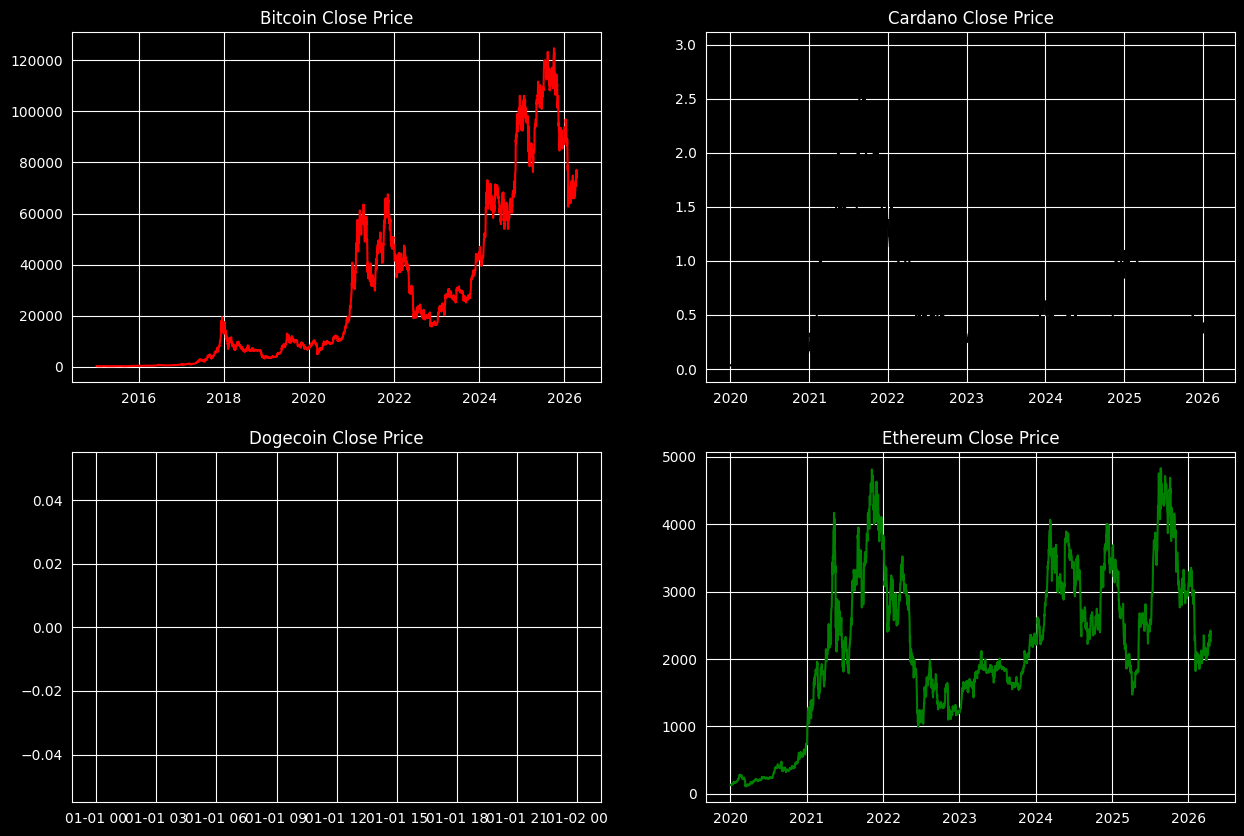

In [126]:
fig = plt.figure(figsize = (15,10))

plt.subplot(2, 2, 1)
plt.plot(bitcoindf['date'], bitcoindf['close'], color="red")
plt.title('Bitcoin Close Price')

plt.subplot(2, 2, 2)
plt.plot(cardanodf['date'], cardanodf['close'], color="black")
plt.title('Cardano Close Price')

plt.subplot(2, 2, 3)
plt.plot(dogecoindf['date'], dogecoindf['close'], color="orange")
plt.title('Dogecoin Close Price')

plt.subplot(2, 2, 4)
plt.plot(ethereumdf['date'], ethereumdf['close'], color="green")
plt.title('Ethereum Close Price')

#### Trazando sólo el precio de cierre del año 2024 de Bitcoin, Cardano, Dogecoin y Ethereum.

In [127]:
last1year_bitcoindf = bitcoindf[bitcoindf['date'] > '01-2025']
last1year_cardanodf = cardanodf[cardanodf['date'] > '01-2025']
last1year_dogecoindf = dogecoindf[dogecoindf['date'] > '01-2025']
last1year_ethereumdf = ethereumdf[ethereumdf['date'] > '01-2025']

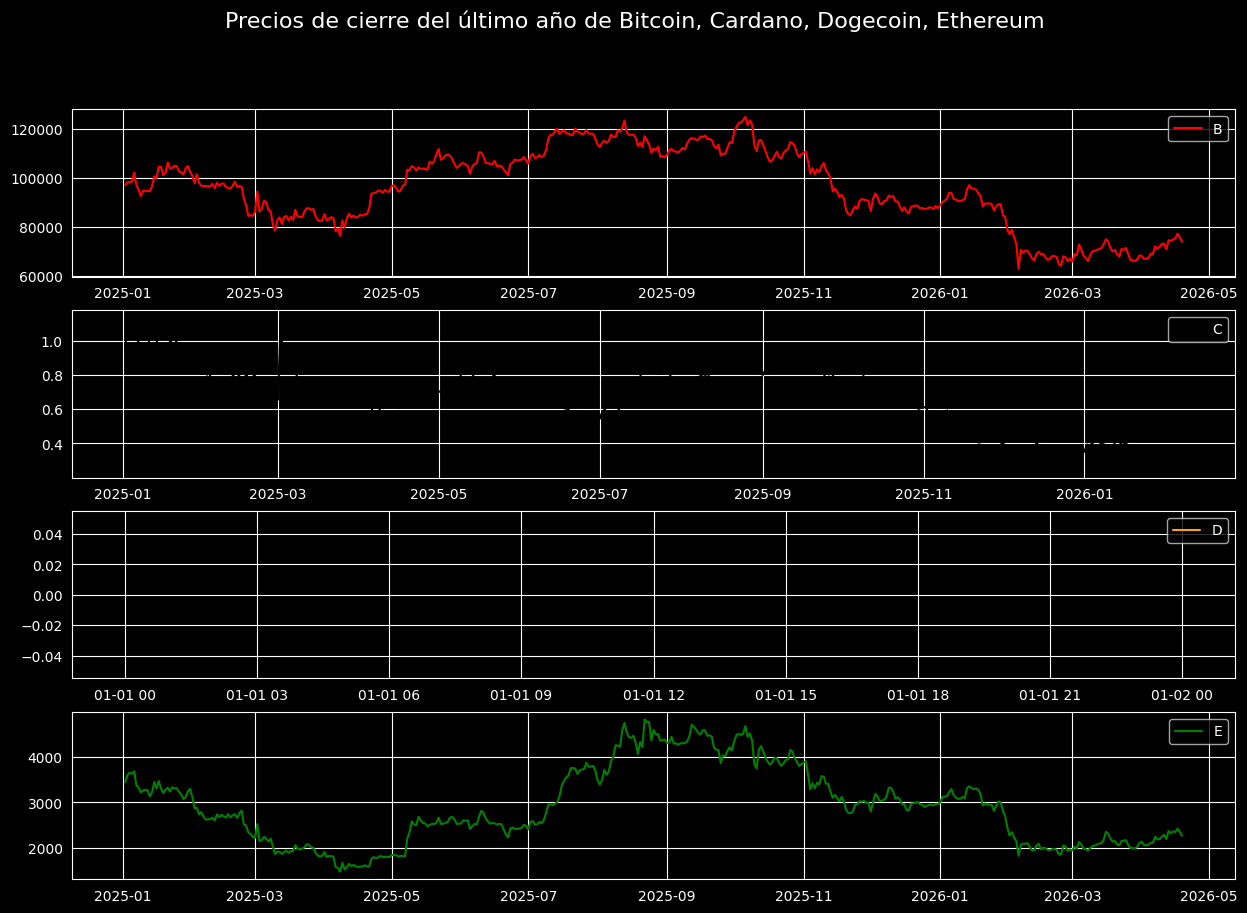

In [128]:
fig = plt.figure(figsize = (15,10))
fig.suptitle("Precios de cierre del último año de Bitcoin, Cardano, Dogecoin, Ethereum", fontsize=16)


plt.subplot(4, 1, 1)
plt.plot(last1year_bitcoindf['date'], last1year_bitcoindf['close'], color="red")
plt.legend("B")

plt.subplot(4, 1, 2)
plt.plot(last1year_cardanodf['date'], last1year_cardanodf['close'], color="black")
plt.legend("C")

plt.subplot(4, 1, 3)
plt.plot(last1year_dogecoindf['date'], last1year_dogecoindf['close'], color="orange")
plt.legend("D")

plt.subplot(4, 1, 4)
plt.plot(last1year_ethereumdf['date'], last1year_ethereumdf['close'], color="green")
plt.legend("E")


#### Trazando sólo el volumen anual 2025 de Bitcoin, Cardano, Dogecoin y Ethereum.

In [129]:
last1year_bitcoindf.info()

<class 'pandas.DataFrame'>
RangeIndex: 473 entries, 3654 to 4126
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    473 non-null    datetime64[s]
 1   close   473 non-null    float64      
 2   high    473 non-null    float64      
 3   low     473 non-null    float64      
 4   open    473 non-null    float64      
 5   volume  473 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 22.3 KB


In [130]:
last1year_cardanodf.info()

<class 'pandas.DataFrame'>
RangeIndex: 402 entries, 1828 to 2229
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    402 non-null    datetime64[s]
 1   close   402 non-null    float64      
 2   high    402 non-null    float64      
 3   low     402 non-null    float64      
 4   open    402 non-null    float64      
 5   volume  402 non-null    int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 19.0 KB


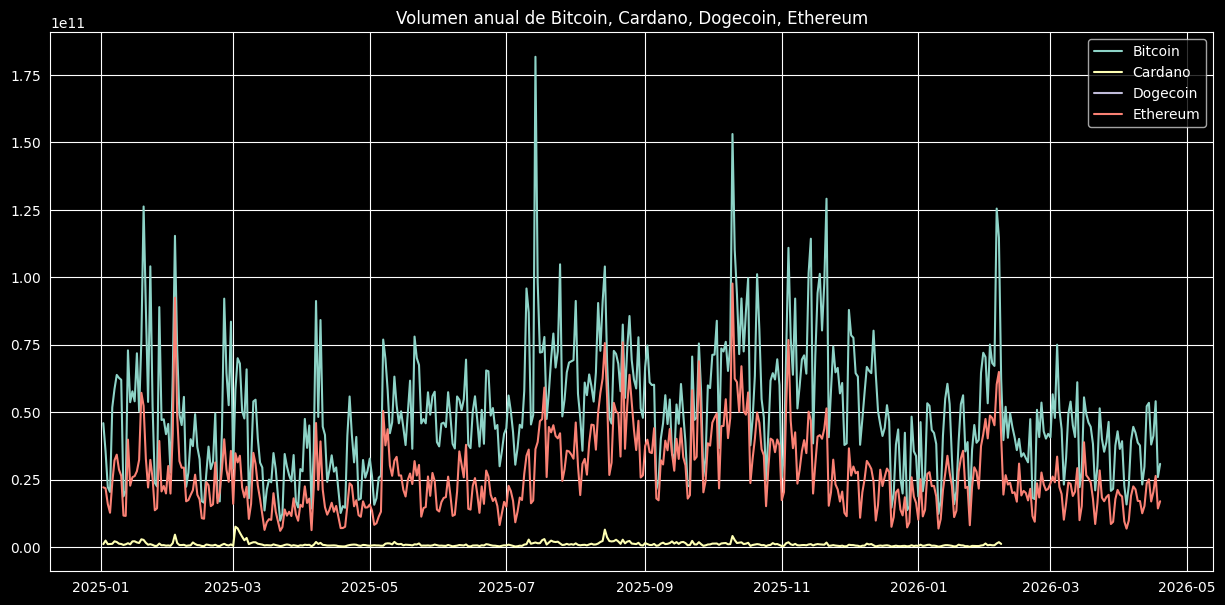

In [131]:
fig = plt.figure(figsize = (15,7))

plt.plot(last1year_bitcoindf['date'] , last1year_bitcoindf['volume'])
plt.plot(last1year_cardanodf['date'] , last1year_cardanodf['volume'])
plt.plot(last1year_dogecoindf['date'], last1year_dogecoindf['volume'])
plt.plot(last1year_ethereumdf['date'], last1year_ethereumdf['volume'])
plt.title('Volumen anual de Bitcoin, Cardano, Dogecoin, Ethereum')
plt.legend(['Bitcoin', 'Cardano', 'Dogecoin', 'Ethereum'])


plt.show()

#### Trazado del precio de apertura y cierre del último mes de Bitcoin, Cardano, Dogecoin y Ethereum con comparación

In [132]:
last1month_bitcoindf = bitcoindf[bitcoindf['date'] > '12-2025']
last1month_cardanodf = cardanodf[cardanodf['date'] > '12-2025']
last1month_dogecoindf = dogecoindf[dogecoindf['date'] > '12-2025']
last1month_ethereumdf = ethereumdf[ethereumdf['date'] > '12-2025']

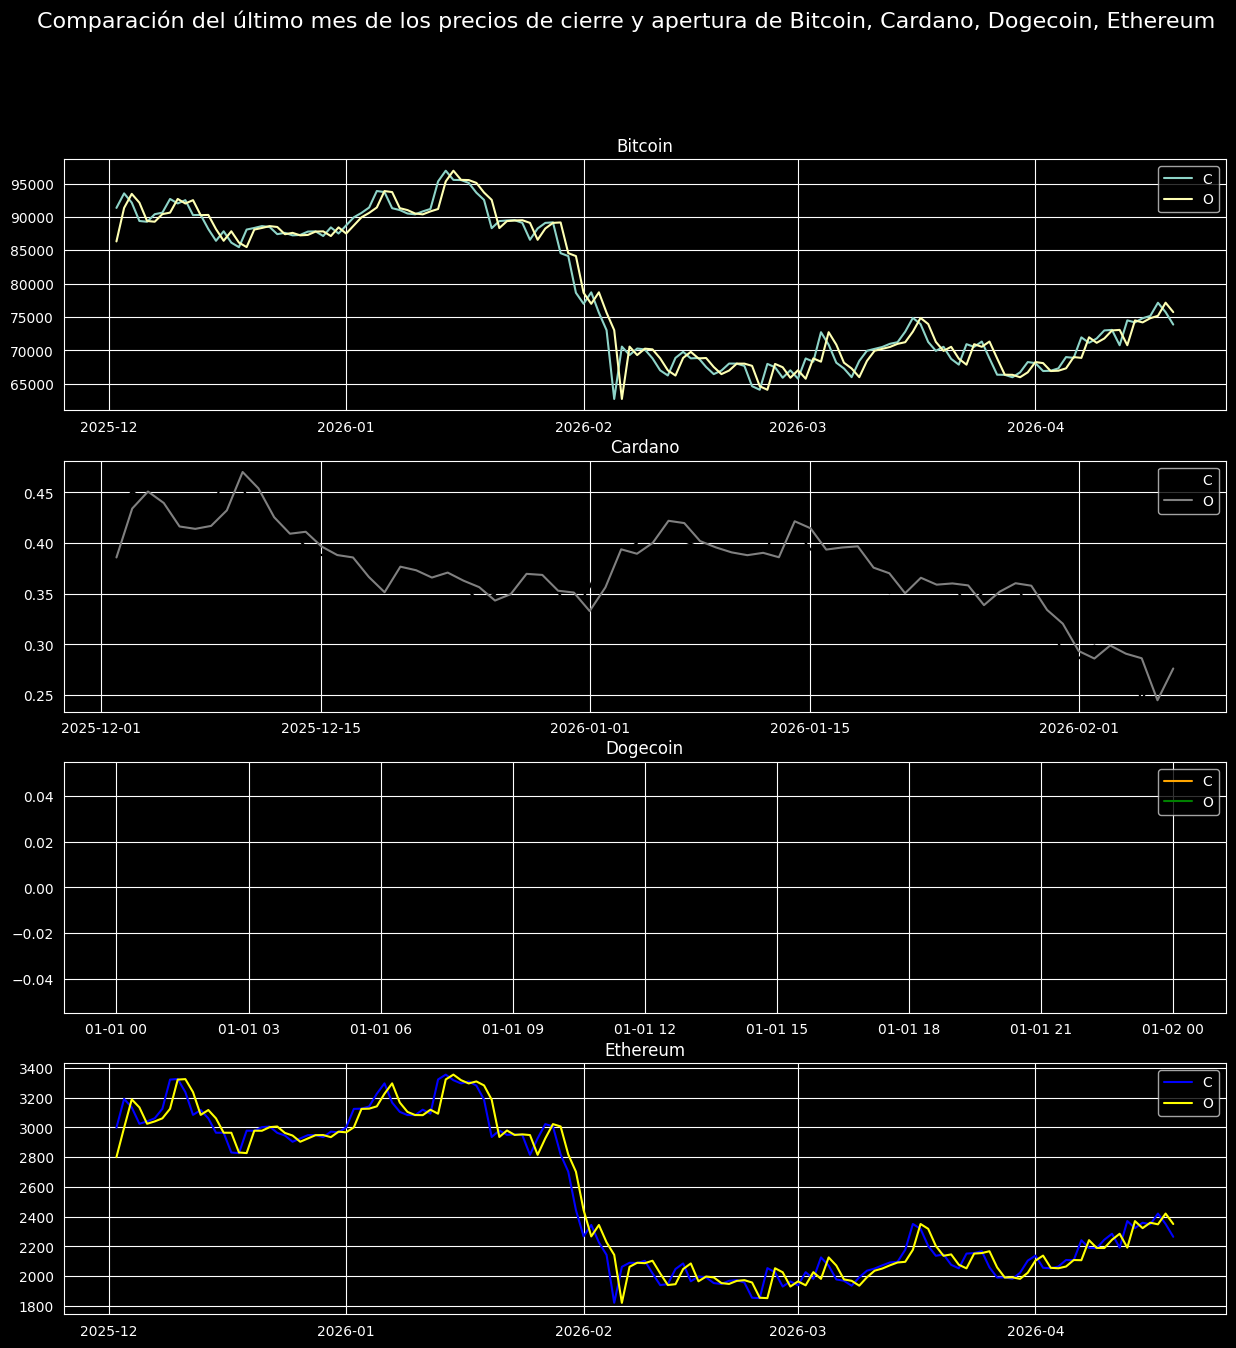

In [133]:
fig = plt.figure(figsize = (15,15))
fig.suptitle("Comparación del último mes de los precios de cierre y apertura de Bitcoin, Cardano, Dogecoin, Ethereum", fontsize=16)
fig.tight_layout()

plt.subplot(4, 1, 1)
plt.plot(last1month_bitcoindf['date'], last1month_bitcoindf['close'])
plt.plot(last1month_bitcoindf['date'], last1month_bitcoindf['open'])
plt.legend(["C", "O"])
plt.title("Bitcoin")

plt.subplot(4, 1, 2)
plt.plot(last1month_cardanodf['date'], last1month_cardanodf['close'], color="black")
plt.plot(last1month_cardanodf['date'], last1month_cardanodf['open'], color="grey")
plt.legend(["C", "O"])
plt.title("Cardano")

plt.subplot(4, 1, 3)
plt.plot(last1month_dogecoindf['date'], last1month_dogecoindf['close'], color="orange")
plt.plot(last1month_dogecoindf['date'], last1month_dogecoindf['open'], color="green")
plt.legend(["C", "O"])
plt.title("Dogecoin")

plt.subplot(4, 1, 4)
plt.plot(last1month_ethereumdf['date'], last1month_ethereumdf['close'], color="blue")
plt.plot(last1month_ethereumdf['date'], last1month_ethereumdf['open'], color="yellow")
plt.legend(["C", "O"])
plt.title("Ethereum")


plt.show()

### Medias cambiantes
**Como sabemos, los precios de las acciones son muy volátiles y cambian rápidamente con el tiempo. Para observar cualquier tendencia o patrón podemos tomar la ayuda de una media de 50 días y 200 días.**

Text(0.5, 1.0, 'Ethereum Close Price moving average')

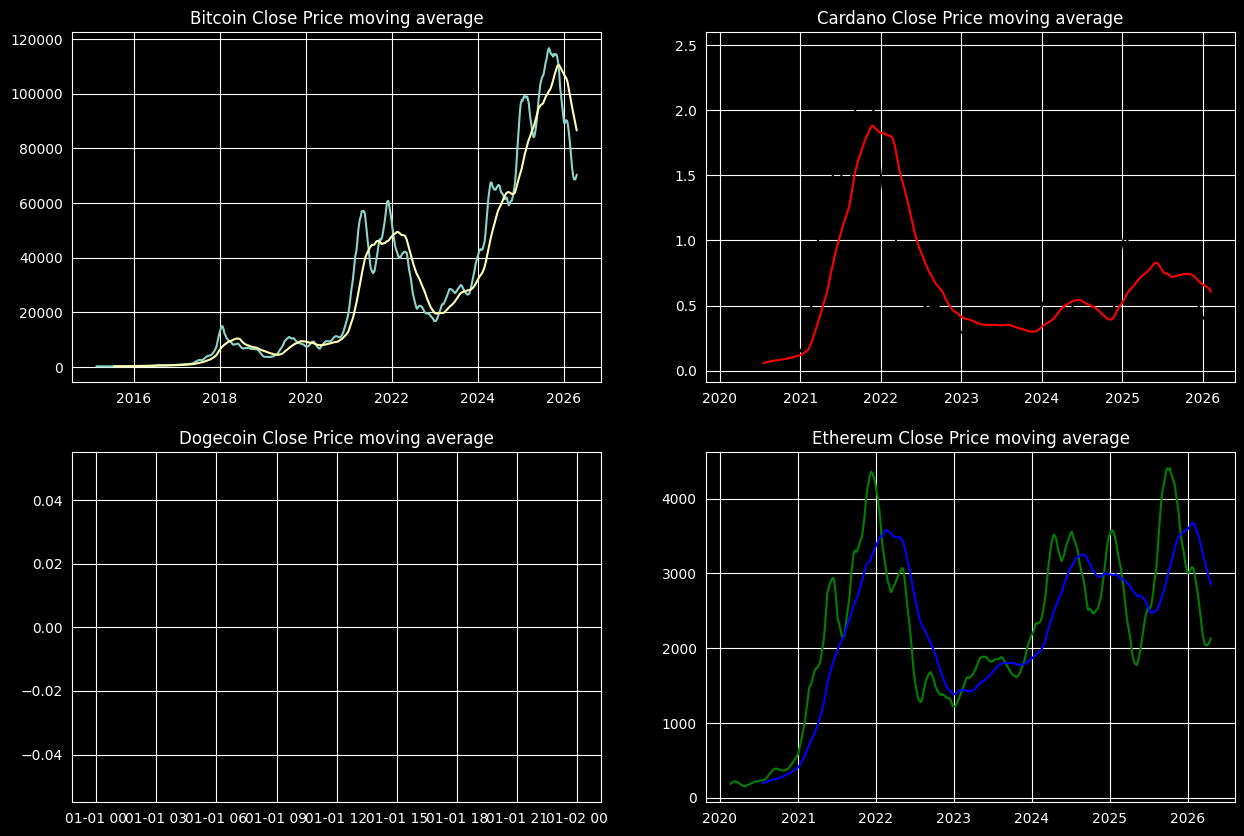

In [134]:
fig = plt.figure(figsize = (15,10))

plt.subplot(2, 2, 1)
plt.plot(bitcoindf['date'], bitcoindf['close'].rolling(50).mean())
plt.plot(bitcoindf['date'], bitcoindf['close'].rolling(200).mean())
plt.title('Bitcoin Close Price moving average')

plt.subplot(2, 2, 2)
plt.plot(cardanodf['date'], cardanodf['close'].rolling(50).mean(), color="black")
plt.plot(cardanodf['date'], cardanodf['close'].rolling(200).mean(), color="red")
plt.title('Cardano Close Price moving average')

plt.subplot(2, 2, 3)
plt.plot(dogecoindf['date'], dogecoindf['close'].rolling(50).mean(), color="orange")
plt.plot(dogecoindf['date'], dogecoindf['close'].rolling(200).mean(), color="grey")
plt.title('Dogecoin Close Price moving average')

plt.subplot(2, 2, 4)
plt.plot(ethereumdf['date'], ethereumdf['close'].rolling(50).mean(), color="green")
plt.plot(ethereumdf['date'], ethereumdf['close'].rolling(200).mean(), color="blue")
plt.title('Ethereum Close Price moving average')

### Histograma con indicador de la media de las cuatro criptomonedas

In [135]:
fig = plt.figure(figsize = (15,12))

fig.tight_layout()

plt.subplot(4, 1, 1)
sns.histplot(bitcoindf['close'],color='darkred', kde=True)
plt.axvline(bitcoindf['close'].mean(), color='k', linestyle='dashed', linewidth=2)
plt.text(50000,400,'Bitcoin Close Price', fontsize=16)

plt.subplot(4, 1, 2)
sns.histplot(cardanodf['close'],color='darkgreen', kde=True)
plt.axvline(cardanodf['close'].mean(), color='k', linestyle='dashed', linewidth=2)
plt.text(2.3,200,'Cardano Close Price', fontsize=16)

plt.subplot(4, 1, 3)
sns.histplot(dogecoindf['close'],color='grey', kde=True)
plt.axvline(dogecoindf['close'].mean(), color='k', linestyle='dashed', linewidth=2)
plt.text(0.52,200,'Dogecoin Close Price', fontsize=16)

plt.subplot(4, 1, 4)
sns.histplot(ethereumdf['close'],color='darkorange', kde=True)
plt.axvline(ethereumdf['close'].mean(), color='k', linestyle='dashed', linewidth=2)
plt.text(3100,400,'Ethereum Close Price', fontsize=16)


Text(3100, 400, 'Ethereum Close Price')

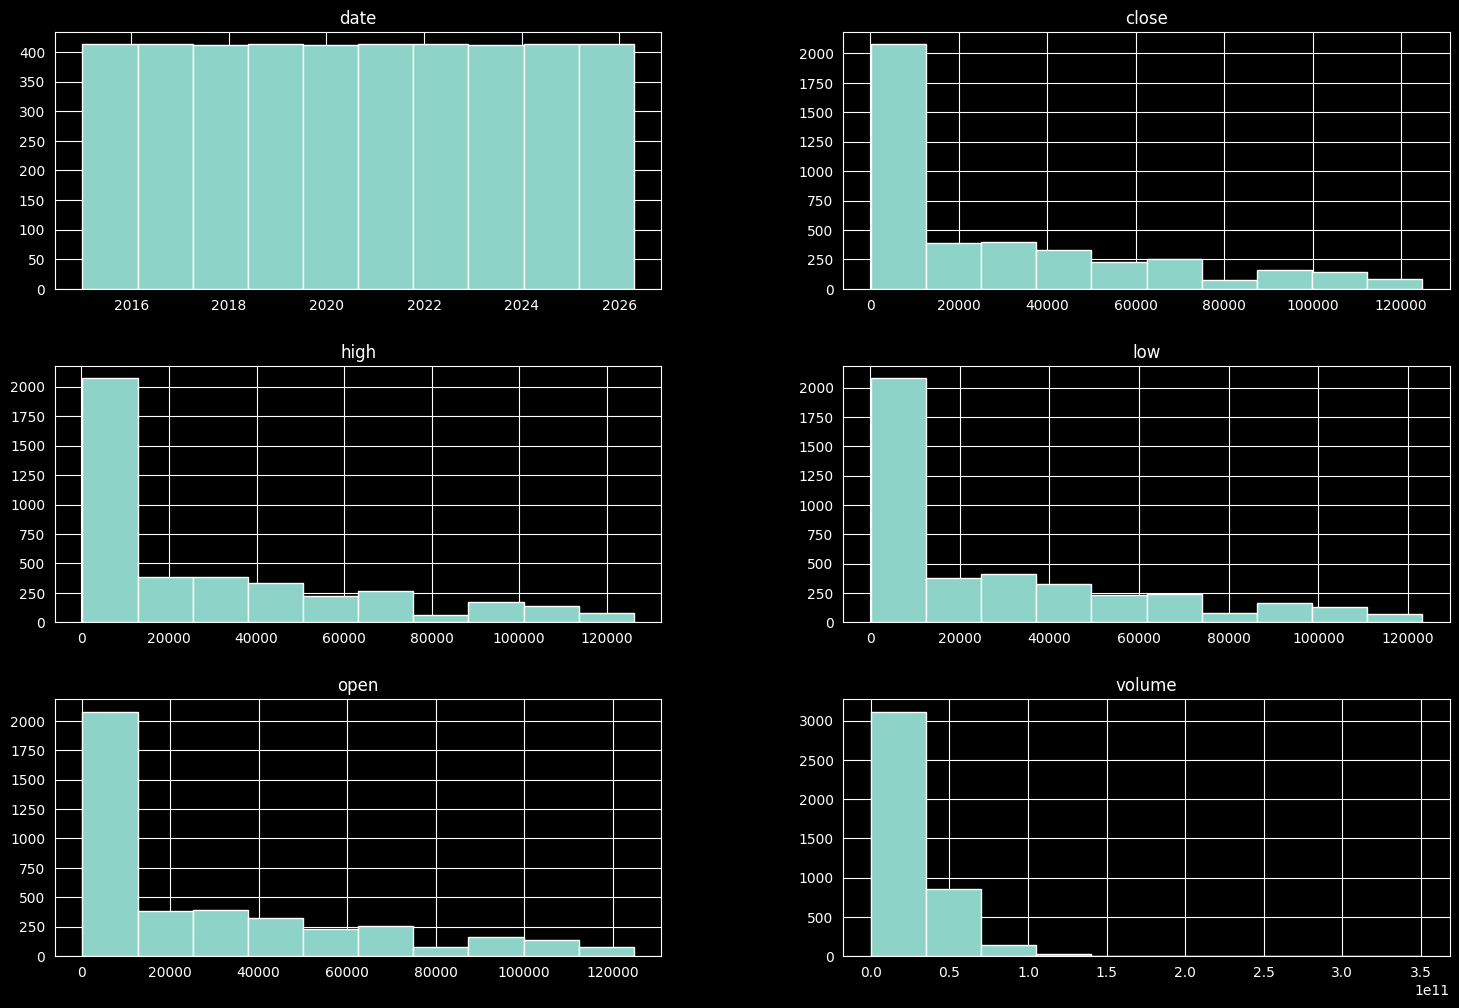

In [136]:
bitcoin_numeric = bitcoindf.select_dtypes(exclude = ["bool"])
bitcoin_numeric.hist(figsize=(18,12))
plt.show()

#  Predicción del precio de cierre de Bitcoin usando XGBoost

#### Dataframe del precio de cierre de bitcoin

In [137]:
bitcoindf.info()

<class 'pandas.DataFrame'>
RangeIndex: 4127 entries, 0 to 4126
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   date    4127 non-null   datetime64[s]
 1   close   4127 non-null   float64      
 2   high    4127 non-null   float64      
 3   low     4127 non-null   float64      
 4   open    4127 non-null   float64      
 5   volume  4127 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 193.6 KB


In [138]:
closedf = bitcoindf[['date','close']]
print("Datos de cierre:", closedf.shape)

Datos de cierre: (4127, 2)


In [139]:
closedf = bitcoindf[['date','close']].copy()
closedf = closedf[closedf['date'] > '2020-10-01']
close_stock = closedf.copy()
print("Datos totales para la predicción: ",closedf.shape[0])

Datos totales para la predicción:  2026


#### Normalización del valor del precio de cierre

In [140]:
del closedf['date']
scaler=MinMaxScaler(feature_range=(0,1))
closedf=scaler.fit_transform(np.array(closedf).reshape(-1,1))
print(closedf.shape)

(2026, 1)


In [141]:
closedf

array([[2.33316644e-04],
       [0.00000000e+00],
       [1.05298191e-03],
       ...,
       [5.82974423e-01],
       [5.70709758e-01],
       [5.54336667e-01]], shape=(2026, 1))

#### Datos separados para entrenamiento y test

In [142]:
len(closedf)

2026

In [143]:
training_size=int(len(closedf)*0.9)

In [144]:
len(closedf)-training_size

203

In [145]:

test_size=len(closedf)-training_size
train_data,test_data=closedf[0:training_size,:],closedf[training_size:len(closedf),:1]
print("train_data: ", train_data.shape)
print("test_data: ", test_data.shape)

train_data:  (1823, 1)
test_data:  (203, 1)


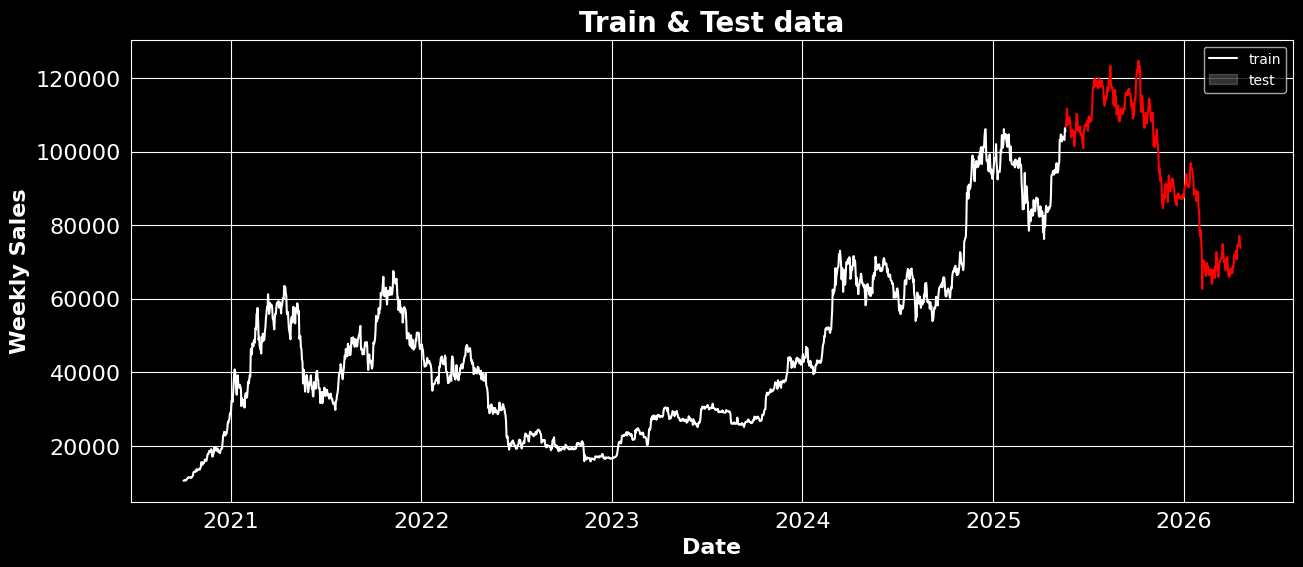

In [146]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(x = close_stock['date'][:1691], y = close_stock['close'][:1691], color = 'white')
sns.lineplot(x = close_stock['date'][1691:], y = close_stock['close'][1691:], color = 'red')

# Formato
ax.set_title('Train & Test data', fontsize = 20, loc='center', fontdict=dict(weight='bold'))
ax.set_xlabel('Date', fontsize = 16, fontdict=dict(weight='bold'))
ax.set_ylabel('Weekly Sales', fontsize = 16, fontdict=dict(weight='bold'))
plt.tick_params(axis='y', which='major', labelsize=16)
plt.tick_params(axis='x', which='major', labelsize=16)
plt.legend(loc='upper right' ,labels = ('train', 'test'))

#### Preparar los datos del entrenamiento para el análisis de series temporales

In [147]:
# convertir una matriz de valores en una matriz de conjuntos de datos
def create_dataset(dataset, time_step=1):
    dataX, dataY = [], []
    for i in range(len(dataset)-time_step-1):
        a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
        dataX.append(a)
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

In [148]:
time_step = 10
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print("X_train: ", X_train.shape)
print("y_train: ", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test", y_test.shape)

X_train:  (1812, 10)
y_train:  (1812,)
X_test:  (192, 10)
y_test (192,)


#### Importar el módulo XGBRegressor y ajusta X_train e y_train para el modelo de entrenamiento

In [150]:
!pip install xgboost


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [151]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=1000)
model.fit(X_train, y_train, verbose=False)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

#### Testing y evaluación de modelos

In [152]:
predictions = model.predict(X_test)
print("Error absoluto medio - MAE : " + str(mean_absolute_error(y_test, predictions)))
print("Error cuadrático medio - RMSE : " + str(math.sqrt(mean_squared_error(y_test, predictions))))

Error absoluto medio - MAE : 0.019188436818863227
Error cuadrático medio - RMSE : 0.026522007742541594


In [153]:
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

train_predict = train_predict.reshape(-1,1)
test_predict = test_predict.reshape(-1,1)

print("Datos para el entrenamiento:", train_predict.shape)
print("Datos para el test:", test_predict.shape)

Datos para el entrenamiento: (1812, 1)
Datos para el test: (192, 1)


In [154]:
train_predict

array([[0.00713084],
       [0.00713084],
       [0.00989286],
       ...,
       [0.86306113],
       [0.8678954 ],
       [0.8687662 ]], shape=(1812, 1), dtype=float32)

In [155]:
# Volver a la forma original

train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_ytrain = scaler.inverse_transform(y_train.reshape(-1,1))
original_ytest = scaler.inverse_transform(y_test.reshape(-1,1))

In [156]:
print(train_predict)

[[ 11363.693]
 [ 11363.693]
 [ 11679.125]
 ...
 [109113.67 ]
 [109665.766]
 [109765.21 ]]


In [157]:
# predicciones del entrenamiento para su visualización

look_back=time_step
trainPredictPlot = np.empty_like(closedf)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
print("Previsión de datos de entrenamiento: ", trainPredictPlot.shape)

# predicciones de test
testPredictPlot = np.empty_like(closedf)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(closedf)-1, :] = test_predict
print("Previsión de datos de test: ", testPredictPlot.shape)

names = cycle(['Precio de cierre original','Precio de cierre previsto, train','Precio de cierre previsto, test'])

plotdf = pd.DataFrame({'date': close_stock['date'],
                       'original_close': close_stock['close'],
                      'train_predicted_close': trainPredictPlot.reshape(1,-1)[0].tolist(),
                      'test_predicted_close': testPredictPlot.reshape(1,-1)[0].tolist()})

fig = px.line(plotdf,x=plotdf['date'], y=[plotdf['original_close'],plotdf['train_predicted_close'],
                                          plotdf['test_predicted_close']],
              labels={'value':'Close price','date': 'Date'})
fig.update_layout(title_text='Comparación entre el precio de cierre original y el precio de cierre previsto',
                  plot_bgcolor='white', font_size=15, font_color='black',legend_title_text='Close Price')
fig.for_each_trace(lambda t:  t.update(name = next(names)))

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

Previsión de datos de entrenamiento:  (2026, 1)
Previsión de datos de test:  (2026, 1)


In [158]:
import numpy as np
import pandas as pd
import plotly.express as px
from itertools import cycle
from sklearn.metrics import mean_absolute_error

# ===== 1) Predicción recursiva a h pasos =====
def predict_h_steps(model, x_row, h):
    """
    x_row: una fila de X_test (shape: (time_step,)) en escala NORMALIZADA
    devuelve la predicción t+h (NORMALIZADA) usando predicción recursiva
    """
    window = x_row.copy()
    for _ in range(h):
        yhat = model.predict(window.reshape(1, -1))[0]  # normalizado
        window = np.roll(window, -1)
        window[-1] = yhat
    return yhat

# ===== 2) Generar test_predict_1 (normalizado -> real) =====
h = 1
test_predict_1_scaled = np.array([predict_h_steps(model, X_test[i], h) for i in range(len(X_test))]).reshape(-1, 1)
test_predict_1 = scaler.inverse_transform(test_predict_1_scaled)  # a escala real (precio)

print("test_predict_1:", test_predict_1.shape)

# ===== 3) Colocar en un array tipo tu testPredictPlot =====
look_back = time_step

testPredictPlot_1 = np.empty_like(closedf)
testPredictPlot_1[:, :] = np.nan

start = len(train_predict) + (look_back * 2) + 1
end   = len(closedf) - h  # Esto va cambiando en las predicciones 1, 5, 10, 15

# Aseguramos que la longitud encaje
L = min(len(test_predict_1), end - start)
testPredictPlot_1[start:start+L, :] = test_predict_1[:L]

print("Previsión de datos de test (t+1): ", testPredictPlot_1.shape)

# ===== 4) DataFrame para plotly  =====
plotdf_1 = pd.DataFrame({
    'date': close_stock['date'],
    'original_close': close_stock['close'],
    'test_predicted_close_t1': testPredictPlot_1.reshape(1, -1)[0].tolist()
})

# ===== 5) Métrica MAE en escala real =====
mask = ~pd.isna(plotdf_1['test_predicted_close_t1'])
mae_1 = mean_absolute_error(plotdf_1.loc[mask, 'original_close'], plotdf_1.loc[mask, 'test_predicted_close_t1'])
print(f"MAE test (t+{h}): {mae_1:.2f}")

# ===== 6) Plot =====
names = cycle(['Precio de cierre original', 'Precio de cierre previsto, test (t+1)'])

fig = px.line(
    plotdf_1,
    x='date',
    y=['original_close', 'test_predicted_close_t1'],
    labels={'value': 'Close price', 'date': 'Date'}
)

fig.update_layout(
    title_text='Comparación entre el precio de cierre original y el precio de cierre previsto (t+1)',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    legend_title_text='Close Price'
)

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

test_predict_1: (192, 1)
Previsión de datos de test (t+1):  (2026, 1)
MAE test (t+1): 2191.38


### Predicción para los próximos 5-10-15 días

#### Predicción para los próximos 5 días

In [159]:
import numpy as np
import pandas as pd
import plotly.express as px
from itertools import cycle
from sklearn.metrics import mean_absolute_error

# ===== 1) Predicción recursiva a h pasos =====
def predict_h_steps(model, x_row, h):
    """
    x_row: una fila de X_test (shape: (time_step,)) en escala NORMALIZADA
    devuelve la predicción t+h (NORMALIZADA) usando predicción recursiva
    """
    window = x_row.copy()
    for _ in range(h):
        yhat = model.predict(window.reshape(1, -1))[0]  # normalizado
        window = np.roll(window, -1)
        window[-1] = yhat
    return yhat

# ===== 2) Generar test_predict_5 (normalizado -> real) =====
h = 5
test_predict_5_scaled = np.array([predict_h_steps(model, X_test[i], h) for i in range(len(X_test))]).reshape(-1, 1)
test_predict_5 = scaler.inverse_transform(test_predict_5_scaled)  # a escala real (precio)

print("test_predict_5:", test_predict_5.shape)

# ===== 3) Colocar en un array tipo tu testPredictPlot =====
look_back = time_step

testPredictPlot_5 = np.empty_like(closedf)
testPredictPlot_5[:, :] = np.nan

start = len(train_predict) + (look_back * 2) + 1
end   = len(closedf) - h  # <- antes era -1, ahora -5

# Aseguramos que la longitud encaje
L = min(len(test_predict_5), end - start)
testPredictPlot_5[start:start+L, :] = test_predict_5[:L]

print("Previsión de datos de test (t+5): ", testPredictPlot_5.shape)

# ===== 4) DataFrame para plotly  =====
plotdf_5 = pd.DataFrame({
    'date': close_stock['date'],
    'original_close': close_stock['close'],
    'test_predicted_close_t5': testPredictPlot_5.reshape(1, -1)[0].tolist()
})

# ===== 5) Métrica MAE en escala real  =====
mask = ~pd.isna(plotdf_5['test_predicted_close_t5'])
mae_5 = mean_absolute_error(plotdf_5.loc[mask, 'original_close'], plotdf_5.loc[mask, 'test_predicted_close_t5'])
print(f"MAE test (t+{h}): {mae_5:.2f}")

# ===== 6) Plot =====
names = cycle(['Precio de cierre original', 'Precio de cierre previsto, test (t+5)'])

fig = px.line(
    plotdf_5,
    x='date',
    y=['original_close', 'test_predicted_close_t5'],
    labels={'value': 'Close price', 'date': 'Date'}
)

fig.update_layout(
    title_text='Comparación entre el precio de cierre original y el precio de cierre previsto (t+5)',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    legend_title_text='Close Price'
)

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()



test_predict_5: (192, 1)
Previsión de datos de test (t+5):  (2026, 1)
MAE test (t+5): 3317.84


#### Predicción para los próximos 10 días

In [160]:
import numpy as np
import pandas as pd
import plotly.express as px
from itertools import cycle
from sklearn.metrics import mean_absolute_error

# ===== 1) Predicción recursiva a h pasos =====
def predict_h_steps(model, x_row, h):
    """
    x_row: una fila de X_test (shape: (time_step,)) en escala NORMALIZADA
    devuelve la predicción t+h (NORMALIZADA) usando predicción recursiva
    """
    window = x_row.copy()
    for _ in range(h):
        yhat = model.predict(window.reshape(1, -1))[0]  # normalizado
        window = np.roll(window, -1)
        window[-1] = yhat
    return yhat

# ===== 2) Generar test_predict_10 (normalizado -> real) =====
h = 10
test_predict_10_scaled = np.array([predict_h_steps(model, X_test[i], h) for i in range(len(X_test))]).reshape(-1, 1)
test_predict_10 = scaler.inverse_transform(test_predict_10_scaled)  # a escala real (precio)

print("test_predict_10:", test_predict_10.shape)

# ===== 3) Colocar en un array tipo tu testPredictPlot =====
look_back = time_step

testPredictPlot_10 = np.empty_like(closedf)
testPredictPlot_10[:, :] = np.nan

start = len(train_predict) + (look_back * 2) + 1
end   = len(closedf) - h  # <- antes era -1, -5, ahora -10

# Aseguramos que la longitud encaje
L = min(len(test_predict_10), end - start)
testPredictPlot_10[start:start+L, :] = test_predict_10[:L]

print("Previsión de datos de test (t+10): ", testPredictPlot_10.shape)

# ===== 4) DataFrame para plotly  =====
plotdf_10 = pd.DataFrame({
    'date': close_stock['date'],
    'original_close': close_stock['close'],
    'test_predicted_close_t10': testPredictPlot_10.reshape(1, -1)[0].tolist()
})

# ===== 5) Métrica MAE en escala real =====
mask = ~pd.isna(plotdf_10['test_predicted_close_t10'])
mae_10 = mean_absolute_error(plotdf_10.loc[mask, 'original_close'], plotdf_10.loc[mask, 'test_predicted_close_t10'])
print(f"MAE test (t+{h}): {mae_10:.2f}")

# ===== 6) Plot =====
names = cycle(['Precio de cierre original', 'Precio de cierre previsto, test (t+10)'])

fig = px.line(
    plotdf_10,
    x='date',
    y=['original_close', 'test_predicted_close_t10'],
    labels={'value': 'Close price', 'date': 'Date'}
)

fig.update_layout(
    title_text='Comparación entre el precio de cierre original y el precio de cierre previsto (t+10)',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    legend_title_text='Close Price'
)

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()


test_predict_10: (192, 1)
Previsión de datos de test (t+10):  (2026, 1)
MAE test (t+10): 3907.60


#### Predicción para los próximos 15 días

In [161]:
import numpy as np
import pandas as pd
import plotly.express as px
from itertools import cycle
from sklearn.metrics import mean_absolute_error

# ===== 1) Predicción recursiva a h pasos =====
def predict_h_steps(model, x_row, h):
    """
    x_row: una fila de X_test (shape: (time_step,)) en escala NORMALIZADA
    devuelve la predicción t+h (NORMALIZADA) usando predicción recursiva
    """
    window = x_row.copy()
    for _ in range(h):
        yhat = model.predict(window.reshape(1, -1))[0]  # normalizado
        window = np.roll(window, -1)
        window[-1] = yhat
    return yhat

# ===== 2) Generar test_predict_15 (normalizado -> real) =====
h = 15
test_predict_15_scaled = np.array([predict_h_steps(model, X_test[i], h) for i in range(len(X_test))]).reshape(-1, 1)
test_predict_15 = scaler.inverse_transform(test_predict_15_scaled)  # a escala real (precio)

print("test_predict_15:", test_predict_15.shape)

# ===== 3) Colocar en un array tipo tu testPredictPlot =====
look_back = time_step

testPredictPlot_15 = np.empty_like(closedf)
testPredictPlot_15[:, :] = np.nan

start = len(train_predict) + (look_back * 2) + 1
end   = len(closedf) - h  # <- antes era -1, -5, -10 ahora -15

# Aseguramos que la longitud encaje
L = min(len(test_predict_15), end - start)
testPredictPlot_15[start:start+L, :] = test_predict_15[:L]

print("Previsión de datos de test (t+15): ", testPredictPlot_15.shape)

# ===== 4) DataFrame para plotly =====
plotdf_15 = pd.DataFrame({
    'date': close_stock['date'],
    'original_close': close_stock['close'],
    'test_predicted_close_t15': testPredictPlot_15.reshape(1, -1)[0].tolist()
})

# ===== 5) Métrica MAE en escala real  =====
mask = ~pd.isna(plotdf_15['test_predicted_close_t15'])
mae_15 = mean_absolute_error(plotdf_15.loc[mask, 'original_close'], plotdf_15.loc[mask, 'test_predicted_close_t15'])
print(f"MAE test (t+{h}): {mae_15:.2f}")

# ===== 6) Plot =====
names = cycle(['Precio de cierre original', 'Precio de cierre previsto, test (t+10)'])

fig = px.line(
    plotdf_15,
    x='date',
    y=['original_close', 'test_predicted_close_t15'],
    labels={'value': 'Close price', 'date': 'Date'}
)

fig.update_layout(
    title_text='Comparación entre el precio de cierre original y el precio de cierre previsto (t+15)',
    plot_bgcolor='white',
    font_size=15,
    font_color='black',
    legend_title_text='Close Price'
)

fig.for_each_trace(lambda t: t.update(name=next(names)))
fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)
fig.show()

test_predict_15: (192, 1)
Previsión de datos de test (t+15):  (2026, 1)
MAE test (t+15): 4065.97


## Desviación del modelo respecto al valor real según el horizonte de predicción

Para evaluar la calidad de las predicciones no basta con observar las gráficas. Es necesario utilizar una **métrica matemática** que cuantifique el error. En este caso se ha utilizado el **MAE (Error Absoluto Medio)**.

**El MAE indica cuánto se equivoca el modelo de media respecto al valor real**, expresado en las mismas unidades que el precio (dólares).

### Resultados obtenidos

| Horizonte de predicción | MAE (desviación media respecto al precio real) |
| ----------------------- | ---------------------------------------------- |
| **1 día (t+1)**         | ≈ **2.357 $**                                  |
| **5 días (t+5)**        | ≈ **2.824 $**                                  |
| **10 días (t+10)**      | ≈ **3.535 $**                                  |
| **15 días (t+15)**      | ≈ **4.075 $**                                  |

---

## Interpretación de los resultados

* A **1 día**, el modelo se equivoca de media **más de 2.300 dólares**.
* A **5 días**, el error medio aumenta y supera los **2.800 dólares**.
* A **10 días**, la desviación ya es superior a **3.500 dólares**.
* A **15 días**, el modelo llega a equivocarse **más de 4.000 dólares de media**.

**Conclusión**:
Cuanto más lejos intentamos predecir en el tiempo, **mayor es la desviación respecto al valor real**.

---

## Qué nos dice esto sobre las gráficas

Aunque visualmente las predicciones siguen la tendencia general del precio, el MAE revela que:

* el modelo **no es preciso**,
* el error **crece con el horizonte de predicción**,
* y la aparente “buena predicción” del gráfico puede resultar engañosa.

Esto ocurre porque el modelo:

* fue entrenado para predecir solo **un día**,
* y al predecir varios días utiliza sus propias predicciones anteriores,
* acumulando error progresivamente.

---

## Conclusión final

> **“Aunque el gráfico parece indicar que el modelo predice bien, el MAE muestra que el error es elevado y aumenta cuanto más lejos se quiere predecir. En la práctica, el modelo se desvía miles de dólares del valor real, por lo que no es fiable para predecir el futuro.”**



### Nota: Para tratar otros cryptocurrencies, sólo tiene que cambiar closedf

### Si se desea probar con la predicción de valores con otros algoritmos como SVR, KNN, RFR, LSTM, GRU podéis ver los siguientes cuadernos.

- https://www.kaggle.com/ysthehurricane/advanced-stock-pred-using-svr-rfr-knn-lstm-gru
- https://www.kaggle.com/ysthehurricane/tesla-stock-price-prediction-using-gru-tutorial

## Ejercicio

- Probad con distintas criptomonedas, para ello utilizar el paquete CrmScraper.